<a href="https://colab.research.google.com/github/thomsmbockchildGod/assignment8AI/blob/main/Assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

#Choose a publicly available dataset suitable for a regression problem
import pandas as pd
import numpy as np
df=pd.read_csv('winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [2]:
#necessary preprocessing steps
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides        

In [5]:
#dropping duplicated value
df.drop_duplicates(inplace=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [16]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df=scaler.fit_transform(df)
df=pd.DataFrame(df)
df

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374,-0.757040
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575,-0.757040
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575,-0.757040
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575,0.457621
4,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374,-0.757040
...,...,...,...,...,...,...,...,...,...,...,...,...
1354,-0.869983,0.494756,-0.983977,-0.461157,-0.407702,1.159265,-0.264277,-0.106490,0.711149,0.945435,-0.861924,0.457621
1355,-1.215536,0.385444,-0.983977,-0.387183,0.038015,1.542281,-0.084619,-0.968269,0.904724,-0.461331,0.062574,-0.757040
1356,-1.388312,0.112167,-0.881656,-0.239233,-0.529261,2.212559,0.124983,-0.850510,1.356397,0.593744,0.709723,0.457621
1357,-1.388312,0.631395,-0.779336,-0.387183,-0.265883,1.542281,-0.084619,-0.663167,1.679021,0.300667,-0.214775,-0.757040


In [32]:
#Applying at least two clustering techniques (e.g., K-means clustering, Hierarchical clustering)

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
kmean=KMeans(n_clusters=3)
kmean.fit(df)
Kmean_labels=kmean.labels_

agglomerative_clustering=AgglomerativeClustering(n_clusters=3)
agglomerative_clustering.fit(df)
aggc_labels=agglomerative_clustering.labels_

print(f"K-means clustering labels: {Kmean_labels}")
print(f"Agglomerative clustering labels: {aggc_labels}")

print(np.unique(Kmean_labels))
print(np.unique(aggc_labels))

K-means clustering labels: [0 0 0 ... 2 0 2]
Agglomerative clustering labels: [2 2 2 ... 2 2 1]
[0 1 2]
[0 1 2]


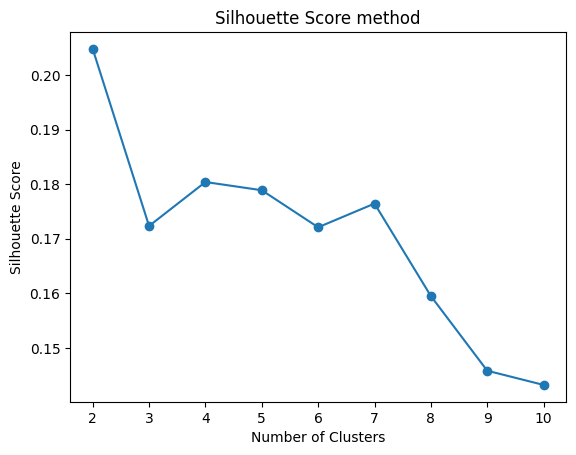

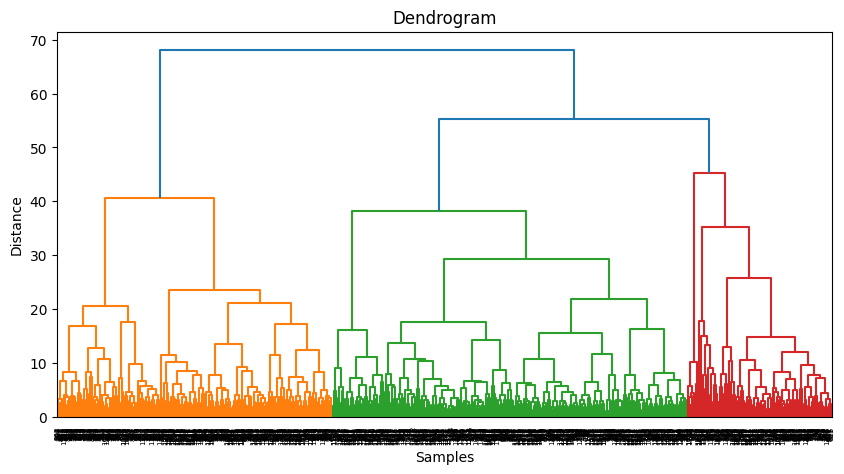

In [26]:
#Determine the optimal number of clusters for each technique
from matplotlib import pyplot as plt
from sklearn.metrics import silhouette_score
score=[]
k_range=range(2,11)
for k in k_range:
    kmean=KMeans(n_clusters=k)
    kmean.fit(df)
    scores=silhouette_score(df,kmean.labels_)
    score.append(scores)
plt.plot(k_range,score,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score method')
plt.show()

from scipy.cluster.hierarchy import dendrogram, linkage
Z=linkage(df,method='ward')
plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

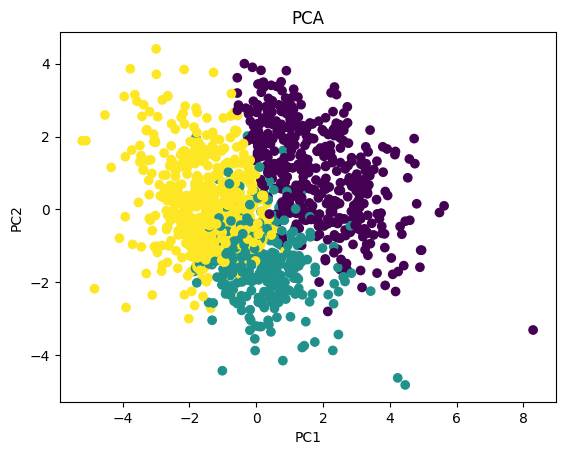

In [30]:
#Implement a dimensionality reduction technique (PCA, t-SNE).
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_df=pca.fit_transform(df)
#Visualize the high-dimensional data in two or three dimensions
plt.scatter(pca_df[:,0],pca_df[:,1],c=Kmean_labels)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()


In [33]:
#Evaluate the models using appropriate metrics (e.g., Silhouette score).
from sklearn.metrics import silhouette_score
print(f"Silhouette score for K-means clustering: {silhouette_score(df,Kmean_labels)}")
print(f"Silhouette score for Agglomerative clustering: {silhouette_score(df,aggc_labels)}")


Silhouette score for K-means clustering: 0.173719317980779
Silhouette score for Agglomerative clustering: 0.1660699791255068


Using the Wine dataset, K-means and Agglomerative Clustering were evaluated using the Silhouette Score.
K-means achieved a higher Silhouette Score than Agglomerative Clustering, indicating better-defined clusters.
Overall, the Wine dataset forms clearer and more natural clusters compared to other datasets, making it well‑suited for unsupervised learning techniques.


#Discuss a hypothetical scenario where your best-performing(Kmean) model is deployed to production.
In a production environment, the best-performing K-means model could be deployed to automatically segment new wine samples based on their chemical properties.
The model would be integrated into an API and used by laboratories or wine distributors to classify wines into meaningful groups, support quality control, and improve recommendation systems.


#Include potential challenges in deployment, such as latency, scalability, and maintenance.

Deploying the best-performing K-means model into production enables automatic clustering of new wine samples based on their chemical properties. This supports quality control, recommendation systems, and wine profiling.
However, deploying a clustering model introduces several challenges. Latency must be controlled to ensure fast responses, especially under high request volumes. Scalability becomes critical as the number of wine samples and users increases. Maintenance is also essential, since data drift can degrade cluster quality over time, requiring regular retraining and monitoring.


#Propose strategies for model monitoring and updating as new data becomes available.

To ensure long-term reliability, the K-means model must be continuously monitored and updated as new wine data becomes available. Monitoring strategies include tracking data drift, cluster stability, centroid distances, and periodic Silhouette Scores.